In [1]:
import json
import cv2
import matplotlib.pyplot as plt

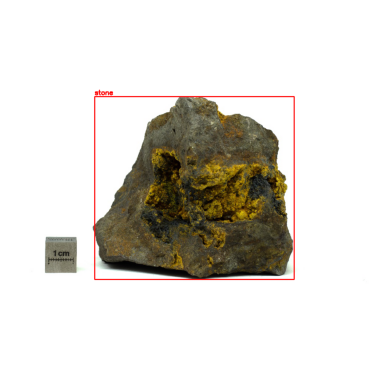

In [3]:
import json
import cv2
import matplotlib.pyplot as plt

# nama file
img_path = "../data/01_raw/mineralimage5k/1_syst/img/1_70018_1_70018.jpg"
json_path = "../data/01_raw/mineralimage5k/1_syst/ann/1_70018_1_70018.jpg.json"

# load gambar
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Gagal load gambar: {img_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# load file json
with open(json_path, "r") as f:
    data = json.load(f)

# ambil bounding box dari struktur DatasetNinja
for obj in data["objects"]:
    label = obj["classTitle"]
    (x1, y1), (x2, y2) = obj["points"]["exterior"]

    # gambar rectangle
    cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
    cv2.putText(image, label, (int(x1), int(y1)-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# tampilkan
plt.imshow(image)
plt.axis("off")
plt.show()


In [ ]:
# folder 1_syst

import os
from glob import glob

# === KONFIGURASI ===
ann_dir = "../data/01_raw/mineralimage5k/1_syst/ann"
img_dir = "../data/01_raw/mineralimage5k/1_syst/img"
output_dir = "../data/01_raw/mineral-dataset"

# === LOOP SEMUA FILE JSON ===
for json_file in glob(os.path.join(ann_dir, "*.json")):
    base_name = os.path.splitext(os.path.basename(json_file))[0]

    # Cari gambar yang mirip nama JSON
    possible_imgs = glob(os.path.join(img_dir, f"{base_name}*"))
    possible_imgs = [p for p in possible_imgs if p.lower().endswith((".jpg", ".jpeg", ".png"))]

    if not possible_imgs:
        print(f"[!] Gambar tidak ditemukan untuk {base_name}")
        continue

    img_path = possible_imgs[0] 

    # Load JSON
    with open(json_file, "r") as f:
        data = json.load(f)

    # Load gambar
    img = cv2.imread(img_path)
    if img is None:
        print(f"[!] Gagal load gambar: {img_path}")
        continue

    # Loop setiap objek bounding box
    for idx, obj in enumerate(data.get("objects", [])):
        label = obj.get("classTitle", "unknown")
        points = obj.get("points", {}).get("exterior", [])

        if len(points) != 2:
            continue

        (x1, y1), (x2, y2) = points
        crop = img[int(y1):int(y2), int(x1):int(x2)]

        # Buat folder sesuai label
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        # Simpan hasil crop
        out_name = f"{os.path.splitext(os.path.basename(img_path))[0]}_{idx}.jpg"
        output_path = os.path.join(label_dir, out_name)
        cv2.imwrite(output_path, crop)

        print(f"[✔] {output_path}")

print("Selesai semua!")

[✔] ../data/01_raw/mineral-dataset/stone/1_59220_1_59220_0.jpg
[✔] ../data/01_raw/mineral-dataset/rock/1_12817_1_12817_0.jpg
[✔] ../data/01_raw/mineral-dataset/mineral/1_12817_1_12817_1.jpg
[✔] ../data/01_raw/mineral-dataset/mineral/1_12817_1_12817_2.jpg
[✔] ../data/01_raw/mineral-dataset/rock/1_12817_1_12817_3.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_25644_1_25644_0.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_25644_1_25644_1.jpg
[✔] ../data/01_raw/mineral-dataset/mineral/1_84223_1_84223_0.jpg
[✔] ../data/01_raw/mineral-dataset/mineral/1_84223_1_84223_1.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_84223_1_84223_2.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_84223_1_84223_3.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_35271_1_35271_0.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_21387_1_21387_0.jpg
[✔] ../data/01_raw/mineral-dataset/stone/1_53547_1_53547_0.jpg
[✔] ../data/01_raw/mineral-dataset/mineral/1_25058_1_25058_0.jpg
[✔] ../data/01_raw/mineral-dataset/rock/1_8028_

In [8]:
# Folder 2_mest

# === KONFIGURASI ===
ann_dir = "../data/01_raw/mineralimage5k/2_mest/ann"
img_dir = "../data/01_raw/mineralimage5k/2_mest/img"
output_dir = "../data/01_raw/mineral-dataset/2_mest"

# === LOOP SEMUA FILE JSON ===
for json_file in glob(os.path.join(ann_dir, "*.json")):
    base_name = os.path.splitext(os.path.basename(json_file))[0]

    # Cari gambar yang mirip nama JSON
    possible_imgs = glob(os.path.join(img_dir, f"{base_name}*"))
    possible_imgs = [p for p in possible_imgs if p.lower().endswith((".jpg", ".jpeg", ".png"))]

    if not possible_imgs:
        print(f"[!] Gambar tidak ditemukan untuk {base_name}")
        continue

    img_path = possible_imgs[0] 

    # Load JSON
    with open(json_file, "r") as f:
        data = json.load(f)

    # Load gambar
    img = cv2.imread(img_path)
    if img is None:
        print(f"[!] Gagal load gambar: {img_path}")
        continue

    # Loop setiap objek bounding box
    for idx, obj in enumerate(data.get("objects", [])):
        label = obj.get("classTitle", "unknown")
        points = obj.get("points", {}).get("exterior", [])

        if len(points) != 2:
            continue

        (x1, y1), (x2, y2) = points
        crop = img[int(y1):int(y2), int(x1):int(x2)]

        # Buat folder sesuai label
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        # Simpan hasil crop
        out_name = f"{os.path.splitext(os.path.basename(img_path))[0]}_{idx}.jpg"
        output_path = os.path.join(label_dir, out_name)
        cv2.imwrite(output_path, crop)

        print(f"[✔] {output_path}")

print("Selesai semua!")

[✔] ../data/01_raw/mineral-dataset/2_mest/mineral/2_7547_FMM_2_7547_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_7547_FMM_2_7547_1.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_32687_FMM_2_32687_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/rock/2_25777_FMM_2_25777_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_8498_FMM_2_8498_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_19385_FMM_2_19385_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_21486_2_21486_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_32971_FMM_2_32971_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_32971_FMM_2_32971_1.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_17815_FMM_2_17815_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_32679_FMM_2_32679_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_8798_FMM_2_8798_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2_30621_FMM_2_30621_0.jpg
[✔] ../data/01_raw/mineral-dataset/2_mest/stone/2

In [9]:
def image_export(ann_dir, img_dir, output_dir):
    # === LOOP SEMUA FILE JSON ===
    for json_file in glob(os.path.join(ann_dir, "*.json")):
        base_name = os.path.splitext(os.path.basename(json_file))[0]

        # Cari gambar yang mirip nama JSON
        possible_imgs = glob(os.path.join(img_dir, f"{base_name}*"))
        possible_imgs = [p for p in possible_imgs if p.lower().endswith((".jpg", ".jpeg", ".png"))]

        if not possible_imgs:
            print(f"[!] Gambar tidak ditemukan untuk {base_name}")
            continue

        img_path = possible_imgs[0] 

        # Load JSON
        with open(json_file, "r") as f:
            data = json.load(f)

        # Load gambar
        img = cv2.imread(img_path)
        if img is None:
            print(f"[!] Gagal load gambar: {img_path}")
            continue

        # Loop setiap objek bounding box
        for idx, obj in enumerate(data.get("objects", [])):
            label = obj.get("classTitle", "unknown")
            points = obj.get("points", {}).get("exterior", [])

            if len(points) != 2:
                continue

            (x1, y1), (x2, y2) = points
            crop = img[int(y1):int(y2), int(x1):int(x2)]

            # Buat folder sesuai label
            label_dir = os.path.join(output_dir, label)
            os.makedirs(label_dir, exist_ok=True)

            # Simpan hasil crop
            out_name = f"{os.path.splitext(os.path.basename(img_path))[0]}_{idx}.jpg"
            output_path = os.path.join(label_dir, out_name)
            cv2.imwrite(output_path, crop)

            print(f"[✔] {output_path}")

    print("Selesai semua!")

In [10]:
# 3_op

ann_dir = "../data/01_raw/mineralimage5k/3_op/ann"
img_dir = "../data/01_raw/mineralimage5k/3_op/img"
output_dir = "../data/01_raw/mineral-dataset/3_op"

image_export(ann_dir, img_dir, output_dir)

[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_392_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1748_cassiterite_Мексика, Гуанахуато_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1945w_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1945w_1.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1628_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1605_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/crystal/3_1605_1.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1519_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1519_1.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1542_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/mineral ore/3_217_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_217_1.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_2140w_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_2140w_1.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_400_0.jpg
[✔] ../data/01_raw/mineral-dataset/3_op/stone/3_1547_0.jpg
[✔] ../data/01_r